# Score-Gap Constrained Log-Sum-Exp Optimization and Sharp Gibbs Bounds

[![Python](https://img.shields.io/badge/Python-3.x-3776AB?logo=python&logoColor=white)](https://www.python.org/)
![Reproducibility](https://img.shields.io/badge/Reproducibility-Computational%20Results-success)
![Numerical Verification](https://img.shields.io/badge/Numerical%20Verification-97.2M%20Vectors-blue)

## Overview

This repository contains the computational material accompanying the paper

**“Score-Gap Constrained Log-Sum-Exp Optimization and Sharp Gibbs Bounds.”**

The paper studies finite-dimensional log-sum-exp optimization over score
vectors subject to a prescribed positive gap between their largest and
second-largest ordered components.

The admissible score set is invariant under additive translations, whereas
the log-sum-exp functional is translation equivariant. Consequently, the
unnormalized optimization problem is unbounded, and the analysis is formulated
using a translation-normalized objective.

The paper establishes an exact extremal characterization, determines the
complete set of maximizing score vectors, and derives an exact representation
of the optimality deficit together with quantitative stability bounds. The
resulting score-space structure yields sharp Gibbs concentration bounds and,
through a majorization relation, sharp bounds for Shannon entropy,
Kullback--Leibler divergence, and effective sample size, with corresponding
Rényi and Tsallis entropy bounds.

The numerical calculations contained in this repository are used to verify
the implementation of the principal proved inequalities over a prescribed
finite computational design. They do not enter the analytical proofs.

---

## Mathematical Framework

Let $h_{(1)} >= h_{(2)} >= ... >= h_{(n)}$
denote the ordered components of a finite-dimensional score vector. The
admissible set is defined by the prescribed positive gap
$h_{(1)} - h_{(2)} = \Delta > 0.$

The analysis considers the scaled log-sum-exp functional under this order
statistic constraint. Because additive translations preserve the score gap
but shift the log-sum-exp objective, the finite extremal problem is formulated
after removing this translation degree of freedom.

The principal analytical results are:

- an exact extremal value for the translation-normalized objective;
- a complete characterization of the maximizing score vectors;
- uniqueness of the maximizing configuration up to additive translations and
  coordinate permutations;
- an exact representation of the optimality deficit;
- two-sided quantitative stability bounds;
- an equivalence between near optimality and collapse of the lower-score
  departures toward the maximizing configuration;
- sharp bounds for the dominant and residual Gibbs masses;
- a majorization relation for every admissible Gibbs vector;
- sharp Shannon entropy, Kullback--Leibler divergence, and effective
  sample-size bounds;
- corresponding Rényi and Tsallis entropy bounds;
- an exact monotone parametrization of the extremal Gibbs and information
  quantities.

Up to additive translations and coordinate permutations, the maximizing score
configuration has two levels: one maximal component and all remaining
components exactly one prescribed score gap below it.

---

In [1]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import RegularGridInterpolator

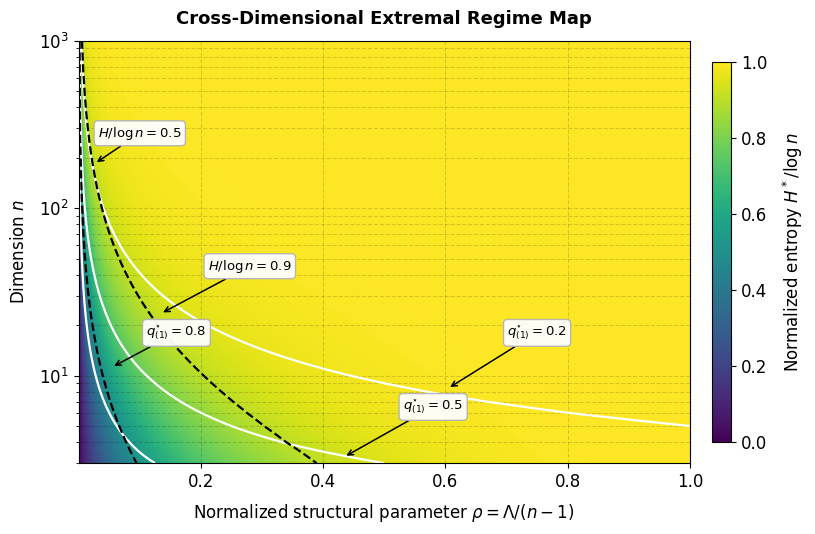

In [2]:
# ==========================================
# Figure 1
# ==========================================
df = pd.read_csv(
    "C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig01_phase_diagram.csv"
)

pivot_H = df.pivot_table(index="n", columns="rho", values="H_over_logn")
pivot_q = df.pivot_table(index="n", columns="rho", values="q1")

rho_raw = pivot_H.columns.to_numpy()
n_raw = pivot_H.index.to_numpy()

log_n_raw = np.log10(n_raw)

rho_fine = np.linspace(rho_raw.min(), rho_raw.max(), 400)
log_n_fine = np.linspace(log_n_raw.min(), log_n_raw.max(), 400)

X_fine, Y_log_fine = np.meshgrid(rho_fine, log_n_fine)
Y_fine = 10**Y_log_fine

interp_H = RegularGridInterpolator((log_n_raw, rho_raw), pivot_H.to_numpy(), bounds_error=False, fill_value=None)
interp_q = RegularGridInterpolator((log_n_raw, rho_raw), pivot_q.to_numpy(), bounds_error=False, fill_value=None)

grid_points = np.array([Y_log_fine.ravel(), X_fine.ravel()]).T
H_fine = interp_H(grid_points).reshape(X_fine.shape)
q_fine = interp_q(grid_points).reshape(X_fine.shape)

plt.rcParams.update({"font.size": 12, "font.family": "sans-serif"})
fig, ax = plt.subplots(figsize=(8.5, 5.5))

im = ax.pcolormesh(
    X_fine, Y_fine, H_fine, shading="gouraud", cmap="viridis", vmin=0, vmax=1
)

c1 = ax.contour(
    X_fine, Y_fine, q_fine, levels=[0.2, 0.5, 0.8], colors="white", linewidths=1.6
)

c2 = ax.contour(
    X_fine,
    Y_fine,
    H_fine,
    levels=[0.5, 0.9],
    colors="black",
    linestyles="dashed",
    linewidths=1.6,
)

arrow_style = dict(arrowstyle="->", color="black", lw=1.1, shrinkA=0, shrinkB=4)
text_style = dict(
    fontsize=9.5,
    color="black",
    weight="semibold",
    va="center",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", alpha=0.95),
)

ax.annotate(
    r"$H/\log n = 0.5$",
    xy=(0.022, 180),
    xytext=(0.10, 280),
    arrowprops=arrow_style,
    **text_style
)

ax.annotate(
    r"$H/\log n = 0.9$",
    xy=(0.13, 23),
    xytext=(0.28, 45),
    arrowprops=arrow_style,
    **text_style
)

ax.annotate(
    r"$q_{(1)}^{\star} = 0.2$",
    xy=(0.60, 8.2),
    xytext=(0.75, 18),
    arrowprops=arrow_style,
    **text_style
)

ax.annotate(
    r"$q_{(1)}^{\star} = 0.5$",
    xy=(0.43, 3.2),
    xytext=(0.58, 6.5),
    arrowprops=arrow_style,
    **text_style
)

ax.annotate(
    r"$q_{(1)}^{\star} = 0.8$",
    xy=(0.05, 11),
    xytext=(0.16, 18),
    arrowprops=arrow_style,
    **text_style
)

ax.set_yscale("log")
ax.set_xlim(rho_fine.min(), rho_fine.max())

ax.set_xlabel(r"Normalized structural parameter $\rho=\Lambda/(n-1)$", labelpad=8)
ax.set_ylabel(r"Dimension $n$", labelpad=8)
ax.set_title(
    r"Cross-Dimensional Extremal Regime Map",
    fontsize=13,
    pad=12,
    weight="bold",
)

ax.grid(True, which="both", linestyle="--", alpha=0.15, color="black")

cbar = fig.colorbar(im, ax=ax, pad=0.03, shrink=0.9)
cbar.set_label(r"Normalized entropy $H^*/\log n$", labelpad=10)

fig.tight_layout()


plt.show()


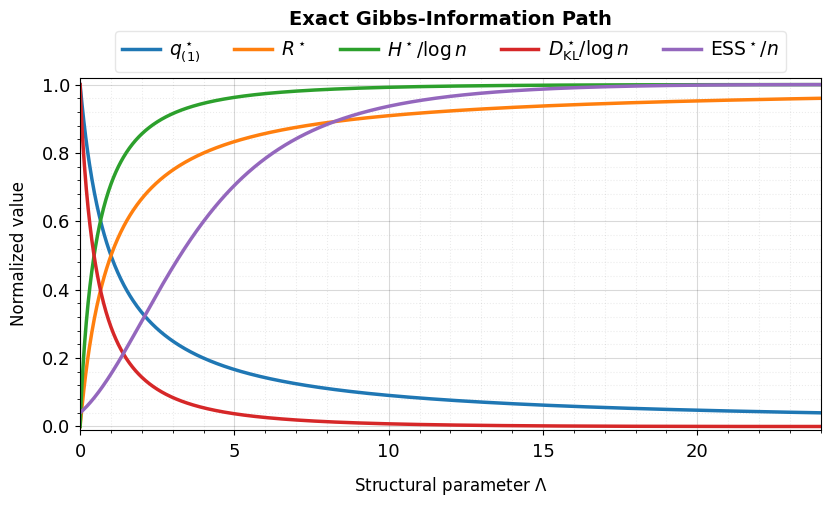

In [3]:
# ==========================================
# Figure 2
# ==========================================

df = pd.read_csv(
    "C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig02_exact_gibbs_information_path.csv"
)

plt.rcParams.update({
    "font.size": 11,
    "font.family": "sans-serif",
    "axes.unicode_minus": False,
})

colors = {
    "q1": "#1f77b4",   # Bleu
    "R": "#ff7f0e",    # Orange
    "H": "#2ca02c",    # Vert
    "KL": "#d62728",   # Rouge
    "ESS": "#9467bd",  # Violet
}

fig, ax = plt.subplots(figsize=(8.5, 5.2))

ax.plot(df["lambda"], df["q1"], color=colors["q1"], linewidth=2.5, label=r"$q_{(1)}^\star$")
ax.plot(df["lambda"], df["R"], color=colors["R"], linewidth=2.5, label=r"$R^\star$")
ax.plot(df["lambda"], df["H_over_logn"], color=colors["H"], linewidth=2.5, label=r"$H^\star/\log n$")
ax.plot(df["lambda"], df["KL_over_logn"], color=colors["KL"], linewidth=2.5, label=r"$D_{\mathrm{KL}}^\star/\log n$")
ax.plot(df["lambda"], df["ESS_over_n"], color=colors["ESS"], linewidth=2.5, label=r"$\mathrm{ESS}^\star/n$")

ax.set_xlabel(r"Structural parameter $\Lambda$", labelpad=10, fontsize=12)
ax.set_ylabel("Normalized value", labelpad=10, fontsize=12)

ax.set_title(
    r"Exact Gibbs-Information Path",
    fontsize=14,
    pad=38,
    weight="bold",
)

ax.set_xlim(df["lambda"].min(), df["lambda"].max())
ax.set_ylim(-0.01, 1.02)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.grid(True, which="major", linestyle="-", alpha=0.15, color="black")
ax.grid(True, which="minor", linestyle=":", alpha=0.08, color="black")

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=5,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    fontsize=13.5,
    columnspacing=1.8,
    handletextpad=0.5,
)

ax.tick_params(axis="x", which="major", labelsize=13, pad=6)
ax.tick_params(axis="y", which="major", labelsize=13)

fig.tight_layout()
plt.show()



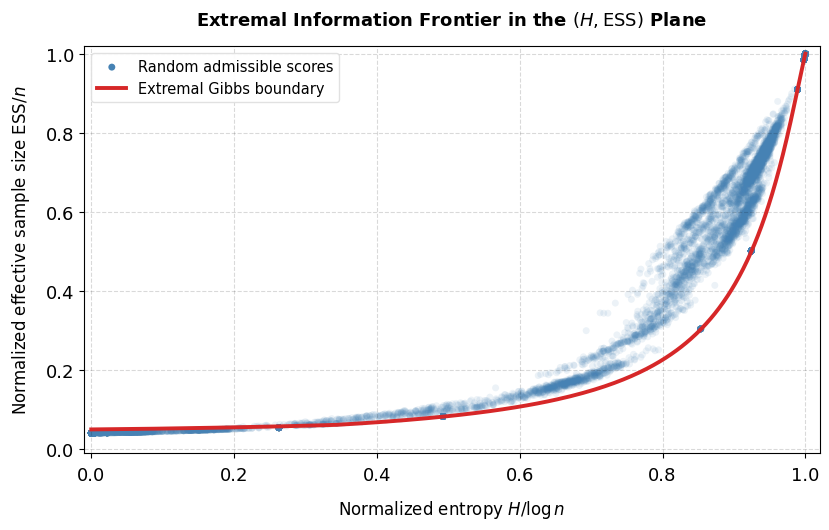

In [4]:
# ==========================================
# Figure 3
# ==========================================


df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig03_information_frontier.csv")

random_df = df[df["type"] == "random"].copy()
frontier_df = df[df["type"] == "boundary"].copy()  # Aligné sur le fichier CSV

frontier_df = frontier_df.sort_values("H_over_logn")

window = max(3, len(frontier_df) // 50)
frontier_df["ESS_smooth"] = frontier_df["ESS_over_n"].rolling(window=window, center=True, min_periods=1).mean()
frontier_df["ESS_clean"] = frontier_df["ESS_smooth"].cummax()

valid_mask = (frontier_df["H_over_logn"] > 0.02) | (frontier_df["ESS_clean"] < 0.2)
frontier_plot = frontier_df[valid_mask]

plt.rcParams.update({
    "font.size": 13,
    "font.family": "sans-serif",
    "axes.unicode_minus": False,
})

fig, ax = plt.subplots(figsize=(8.5, 5.5))

scatter_points = ax.scatter(
    random_df["H_over_logn"],
    random_df["ESS_over_n"],
    s=25,
    color="#4682b4",
    alpha=0.1,
    edgecolors="none",
    label="Random admissible scores",
)

line_frontier, = ax.plot(
    frontier_plot["H_over_logn"],
    frontier_plot["ESS_clean"],
    color="#d62728",
    linewidth=2.8,
    zorder=3,
    label="Extremal Gibbs boundary",
)

ax.set_xlabel(r"Normalized entropy $H / \log n$", labelpad=10, fontsize=12)
ax.set_ylabel(
    r"Normalized effective sample size $\mathrm{ESS} / n$", labelpad=10, fontsize=12
)
ax.set_title(
    r"Extremal Information Frontier in the $(H, \mathrm{ESS})$ Plane",
    fontsize=13,
    pad=15,
    weight="bold",
)

ax.set_xlim(-0.01, 1.02)
ax.set_ylim(-0.01, 1.02)
ax.grid(True, which="major", linestyle="--", alpha=0.15, color="black")

leg = ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=10.5,
)

ax.tick_params(axis="x", which="major", labelsize=13, pad=6)
ax.tick_params(axis="y", which="major", labelsize=13)

for lh in leg.legend_handles:
    lh.set_alpha(1.0)

fig.tight_layout()
plt.show()



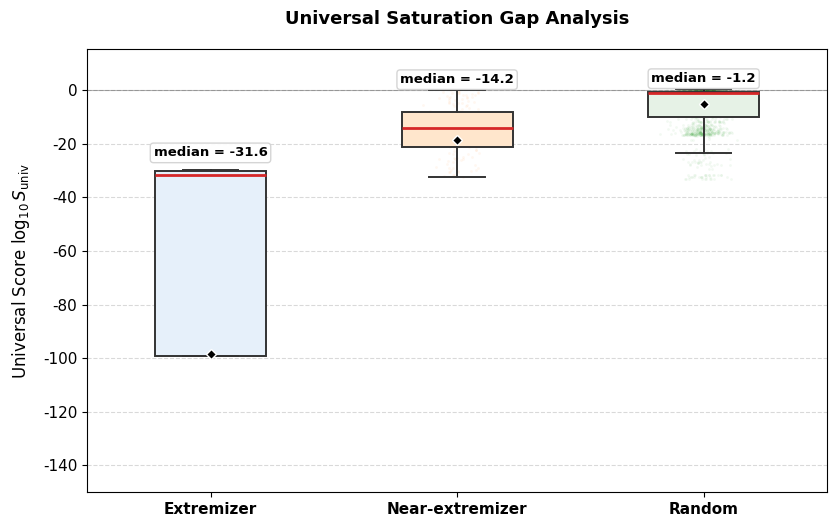

In [5]:
# ==========================================
# Figure 4
# ==========================================

df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig04_saturation_gap.csv")

order = ["extremizer", "near_extremizer", "random"]
labels = ["Extremizer", "Near-extremizer", "Random"]

data = [df.loc[df["case"] == c, "log10_universal_score"].dropna().to_numpy() for c in order]

box_colors = ["#e6f0fa", "#ffe6cc", "#e6f2e6"]
jitter_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.unicode_minus": False,
})

fig, ax = plt.subplots(figsize=(8.5, 5.4))

bp = ax.boxplot(
    data,
    positions=np.arange(1, 4),
    widths=0.45,
    patch_artist=True,
    showfliers=False,
    showmeans=True,
    medianprops=dict(color="#d62728", linewidth=2.0),  # Ligne médiane rouge académique
    meanprops=dict(
        marker="D",
        markerfacecolor="black",
        markeredgecolor="white",
        markersize=5,
    ),
    boxprops=dict(linewidth=1.4, edgecolor="#333333"),
    whiskerprops=dict(linewidth=1.4, color="#333333"),
    capprops=dict(linewidth=1.4, color="#333333"),
    zorder=2,
)

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)

rng = np.random.default_rng(123)

for i, values in enumerate(data):
    if len(values) > 2000:
        values_plot = rng.choice(values, size=2000, replace=False)
    else:
        values_plot = values

    x = rng.normal(loc=i + 1, scale=0.05, size=len(values_plot))

    ax.scatter(
        x,
        values_plot,
        s=4,
        color=jitter_colors[i],
        alpha=0.06,
        linewidths=0,
        zorder=1,
    )

for i, c in enumerate(order):
    values = df.loc[df["case"] == c, "log10_universal_score"].dropna()
    median = values.median()

    q75 = values.quantile(0.75)
    q25 = values.quantile(0.25)
    iqr = q75 - q25
    upper_whisker = values[values <= (q75 + 1.5 * iqr)].max()
    y_pos = upper_whisker + 4.0 if upper_whisker < -5 else upper_whisker + 1.5

    ax.text(
        i + 1,
        y_pos,
        f"median = {median:.1f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        weight="semibold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="#d3d3d3",
            alpha=0.95,
        ),
    )

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels, weight="semibold")

ax.set_ylabel(r"Universal Score $\log_{10} S_{\mathrm{univ}}$", fontsize=12, labelpad=8)
ax.set_title("Universal Saturation Gap Analysis", fontsize=13, weight="bold", pad=18)

ax.grid(axis="y", linestyle="--", alpha=0.15, color="black")
ax.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.3)

ax.set_ylim(df["log10_universal_score"].min()/2 ,df["log10_universal_score"].max() + 15)

fig.tight_layout()
plt.show()



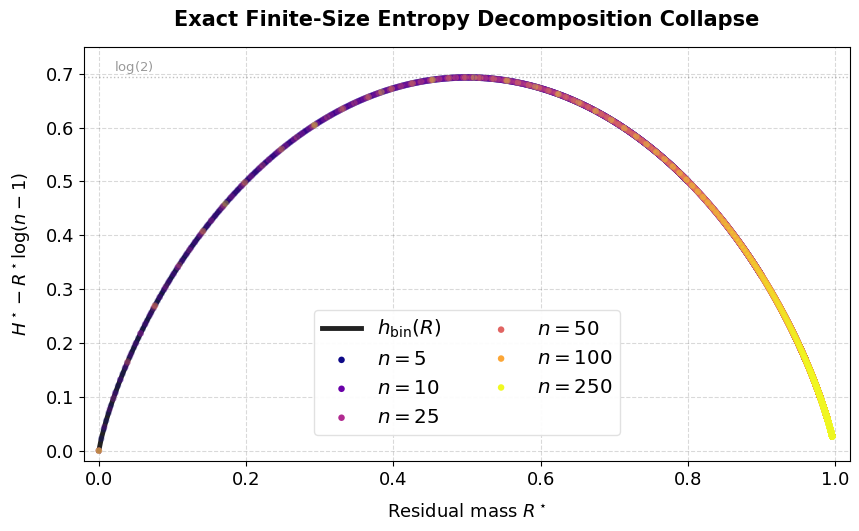

In [6]:
# ==========================================
# Figure 5
# ==========================================


df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig05_entropy_decomposition_collapse.csv")

theory = df[["R", "binary_entropy_R"]].drop_duplicates().sort_values("R")

n_values = sorted(df["n"].unique())
num_n = len(n_values)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.unicode_minus": False,
})

fig, ax = plt.subplots(figsize=(8.8, 5.5))

cmap = plt.get_cmap("plasma")
ax.plot(
    theory["R"],
    theory["binary_entropy_R"],
    color="#222222",
    linestyle="-",
    linewidth=3.5,
    zorder=2,
    label=r"$h_{\mathrm{bin}}(R)$",
)

for idx, n_value in enumerate(n_values):
    sub = df[df["n"] == n_value].sort_values("R")
    color_fraction = idx / (num_n - 1) if num_n > 1 else 0.5

    ax.scatter(
        sub["R"],
        sub["entropy_binary_part"],
        s=22,
        color=cmap(color_fraction),
        alpha=0.30,
        edgecolors="none",
        zorder=4,
        label=rf"$n={int(n_value)}$"
    )

ax.set_xlabel(r"Residual mass $R^\star$", labelpad=10, fontsize=13)
ax.set_ylabel(r"$H^\star - R^\star \log(n-1)$", labelpad=10, fontsize=13)
ax.set_title("Exact Finite-Size Entropy Decomposition Collapse", fontsize=15, weight="bold", pad=15)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 0.75)

ax.grid(True, linestyle="--", alpha=0.15, color="black")

ax.axhline(0.69315, color="black", linestyle=":", alpha=0.25, linewidth=1.0)
ax.text(0.02, 0.705, r"$\log(2)$", color="black", alpha=0.4, fontsize=9.5)

leg = ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.04),
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=14.3,
    ncol=2,
)

for lh in leg.legend_handles:
    if hasattr(lh, "set_alpha"):
        lh.set_alpha(1.0)

fig.tight_layout()
plt.show()


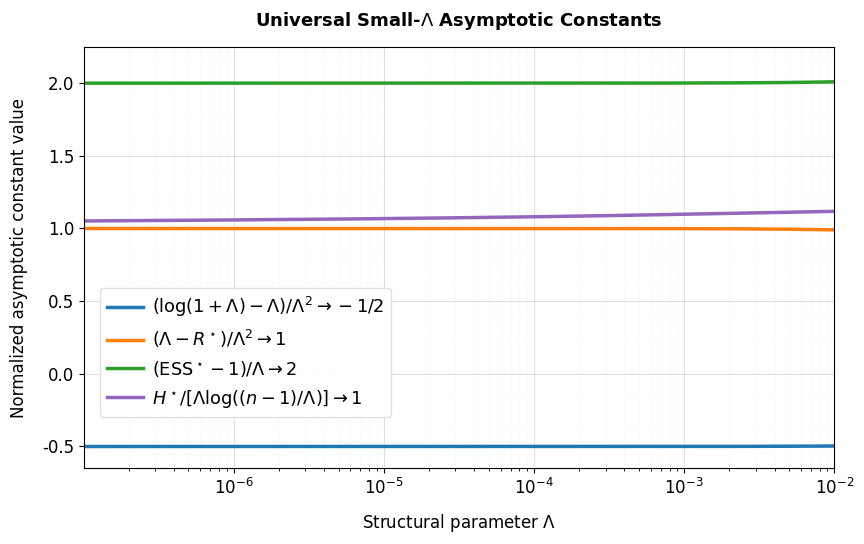

In [7]:
# ==========================================
# Figure 6
# ==========================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.unicode_minus": False,
})

colors = {
    "vbar": "#1f77b4",  # Bleu
    "R": "#ff7f0e",  # Orange
    "ESS": "#2ca02c",  # Vert
    "H": "#9467bd",  # Violet
}


df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig06_small_lambda_constants_plot.csv")
df = df.sort_values("lambda")

fig, ax = plt.subplots(figsize=(8.8, 5.6))

ax.plot(df["lambda"], df["c_vbar"], color=colors["vbar"], linewidth=2.5, label=r"$(\log(1+\Lambda)-\Lambda)/\Lambda^2 \to -1/2$")
ax.plot(df["lambda"], df["c_R"], color=colors["R"], linewidth=2.5, label=r"$(\Lambda-R^\star)/\Lambda^2 \to 1$")
ax.plot(df["lambda"], df["c_ESS"], color=colors["ESS"], linewidth=2.5, label=r"$(\mathrm{ESS}^\star-1)/\Lambda \to 2$")
ax.plot(df["lambda"], df["c_H"], color=colors["H"], linewidth=2.5, label=r"$H^\star/[\Lambda\log((n-1)/\Lambda)] \to 1$")

x_min, x_max = df["lambda"].min(), df["lambda"].max()

ax.set_xscale("log")

ax.set_xlabel(r"Structural parameter $\Lambda$", labelpad=10, fontsize=12)
ax.set_ylabel("Normalized asymptotic constant value", labelpad=10, fontsize=12)

ax.set_title(r"Universal Small-$\Lambda$ Asymptotic Constants", fontsize=13, weight="bold", pad=15)

ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.65, 2.25)

ax.grid(True, which="major", linestyle="-", alpha=0.12, color="black")
ax.grid(True, which="minor", linestyle=":", alpha=0.06, color="black")


ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.45),
    ncol=1,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=12.8,
    columnspacing=1.4,
    handletextpad=0.5
)

fig.tight_layout()
plt.show()


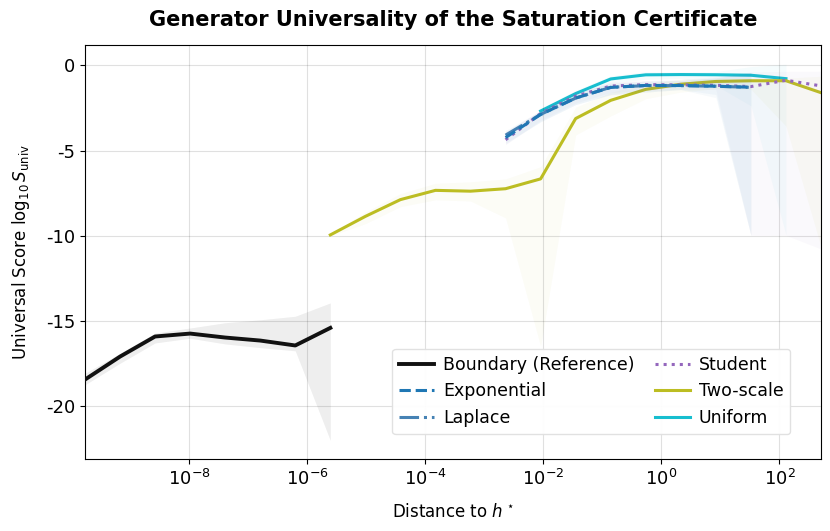

In [8]:
# ==========================================
# Figure 7
# ==========================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.unicode_minus": False,
})


df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig07_generator_universality.csv")

generators = ["boundary", "exponential", "laplace", "student", "two_scale", "uniform"]

fig, ax = plt.subplots(figsize=(8.5, 5.5))

gen_styles = {
    "boundary": {"color": "#111111", "lw": 2.8, "ls": "-", "zorder": 10, "label": "Boundary (Reference)"},
    "exponential": {"color": "#1f77b4", "lw": 2.2, "ls": "--", "zorder": 5, "label": "Exponential"},
    "laplace": {"color": "#4682b4", "lw": 2.2, "ls": "-.", "zorder": 4, "label": "Laplace"},
    "student": {"color": "#9467bd", "lw": 2.2, "ls": ":", "zorder": 3, "label": "Student"},
    "two_scale": {"color": "#bcbd22", "lw": 2.2, "ls": "-", "zorder": 2, "label": "Two-scale"},
    "uniform": {"color": "#17becf", "lw": 2.2, "ls": "-", "zorder": 1, "label": "Uniform"},
}


for gen in generators:
    sub = (
        df[df["generator"] == gen]
        .dropna(subset=["distance_mid", "median_log10_score", "q25_log10_score", "q75_log10_score"])
        .sort_values("distance_mid")
    )

    if sub.empty:
        continue

    x = sub["distance_mid"].to_numpy()
    y = sub["median_log10_score"].to_numpy()
    y_low = sub["q25_log10_score"].to_numpy()
    y_high = sub["q75_log10_score"].to_numpy()

    style = gen_styles[gen]

    ax.plot(
        x,
        y,
        color=style["color"],
        linewidth=style["lw"],
        linestyle=style["ls"],
        zorder=style["zorder"],
        label=style["label"]
    )

    ax.fill_between(
        x,
        y_low,
        y_high,
        color=style["color"],
        alpha=0.04 if gen != "boundary" else 0.07,
        linewidth=0,
        zorder=style["zorder"] - 0.5
    )

ax.set_xscale("log")

ax.set_xlabel(r"Distance to $h^\star$", labelpad=10, fontsize=12)
ax.set_ylabel(r"Universal Score $\log_{10} S_{\mathrm{univ}}$", labelpad=10, fontsize=12)

ax.set_title(
    "Generator Universality of the Saturation Certificate",
    fontsize=15,
    weight="bold",
    pad=14,
)

ax.set_xlim(df["distance_mid"].min(), df["distance_mid"].max())

ax.grid(True, which="major", linestyle="-", alpha=0.12, color="black")
ax.grid(True, which="minor", linestyle=":", alpha=0.06, color="black")

leg = ax.legend(
    loc="lower right",
    bbox_to_anchor=(0.97, 0.04),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=12.5,
    columnspacing=1.2,
    handletextpad=0.5
)

for lh in leg.legend_handles:
    if hasattr(lh, "set_alpha"):
        lh.set_alpha(1.0)

fig.tight_layout()
plt.show()



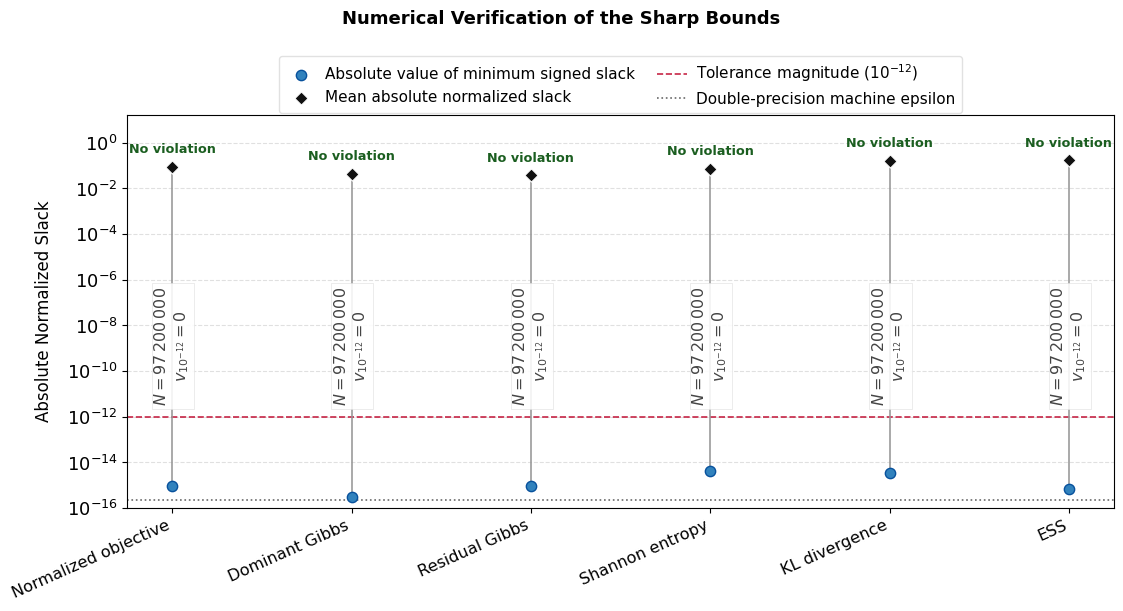

In [9]:
# ==========================================
# Figure 8
# ==========================================



CSV_PATH = (
    "C:/Users/fredy/Downloads/"
    "Results_Extremal_Gibbs_Q1PP_V3_Final/"
    "figure_data/v3_fig08_theorem_dashboard.csv"
)

TOL = 1e-12

MACHINE_EPS = np.finfo(float).eps

PLOT_FLOOR = 1e-18

df = pd.read_csv(CSV_PATH)


# ---------------------------------------------------------------------
# Input audit
# ---------------------------------------------------------------------

required_columns = {
    "theorem",
    "minimum_relative_slack",
    "mean_relative_slack",
    "tests",
    "violations_tol_1e_minus_12",
}

missing_columns = required_columns.difference(df.columns)

numeric_columns = ["minimum_relative_slack", "mean_relative_slack", "tests", "violations_tol_1e_minus_12"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="raise")

slack_array = df[["minimum_relative_slack", "mean_relative_slack"]].to_numpy(dtype=float)


observed_counts = df["tests"].astype(int).unique()

N_EVALUATED = int(observed_counts[0])


# ---------------------------------------------------------------------
# Labels aligned with the current manuscript
# ---------------------------------------------------------------------

label_map = {
    "Theorem 4": "Normalized objective",
    "Theorem 5": "Dominant Gibbs",
    "Corollary 5": "Residual Gibbs",
    "Theorem 6-H": "Shannon entropy",
    "Theorem 6-KL": "KL divergence",
    "Theorem 6-ESS": "ESS",
}

df["display_label"] = df["theorem"].map(label_map)
unmapped_labels = df.loc[df["display_label"].isna(),"theorem"].astype(str).tolist()
df["min_signed_slack"] = (df["minimum_relative_slack"].astype(float))
df["mean_signed_slack"] = (df["mean_relative_slack"].astype(float))
df["abs_min_slack"] = np.abs(df["min_signed_slack"])
df["abs_mean_slack"] = np.abs(df["mean_signed_slack"])
df["plot_min_slack"] = np.maximum(df["abs_min_slack"], PLOT_FLOOR)
df["plot_mean_slack"] = np.maximum(df["abs_mean_slack"], PLOT_FLOOR)
df["display_status"] = np.where(df["violations_tol_1e_minus_12"].astype(int) == 0, "No violation", "Violation detected")

# ---------------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11.5, 6.2))

x = np.arange(len(df))

ax.scatter(
    x,
    df["plot_min_slack"],
    marker="o",
    s=55,
    color="#3182bd",
    edgecolor="#08519c",
    linewidth=1.0,
    zorder=4,
    label="Absolute value of minimum signed slack",
)

ax.scatter(
    x,
    df["plot_mean_slack"],
    marker="D",
    s=45,
    color="#111111",
    edgecolor="white",
    linewidth=0.8,
    zorder=5,
    label="Mean absolute normalized slack",
)

for i in range(len(df)):

    y1 = df["plot_min_slack"].iloc[i]
    y2 = df["plot_mean_slack"].iloc[i]
    ax.vlines(
        x[i],
        min(y1, y2),
        max(y1, y2),
        colors="#969696",
        linestyles="-",
        linewidth=1.15,
        zorder=3,
    )

ax.axhline(
    TOL,
    color="#bd0026",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    zorder=2,
    label=r"Tolerance magnitude ($10^{-12}$)"
)

ax.axhline(
    MACHINE_EPS,
    color="#4d4d4d",
    linestyle=":",
    linewidth=1.2,
    alpha=0.85,
    zorder=2,
    label="Double-precision machine epsilon",
)


for i, row in df.iterrows():
    violations = int(row["violations_tol_1e_minus_12"])
    status_color = ("#1b5e20" if violations == 0 else "#b71c1c")

    # Status above mean marker
    ax.text(
        i,
        row["plot_mean_slack"] * 3.0,
        row["display_status"],
        ha="center",
        va="bottom",
        fontsize=9.2,
        weight="bold",
        color=status_color,
        zorder=6,
    )

    # Evaluation count and violation count
    ax.text(
        i,
        0.26,
        rf"$N=97\,200\,000$"
        + "\n"
        + rf"$v_{{10^{{-12}}}}={violations}$",
        ha="center",
        va="bottom",
        fontsize=11.5,
        color="#444444",
        rotation=90,
        weight="medium",
        transform=ax.get_xaxis_transform(),
        zorder=6,
        bbox=dict(
            boxstyle="square,pad=0.20",
            facecolor="white",
            edgecolor="#e0e0e0",
            linewidth=0.5,
            alpha=0.88,
        ),
    )

ax.set_yscale("log")

y_max_data = max(
    float(df["plot_mean_slack"].max()),
    float(df["plot_min_slack"].max()),
    TOL)

ax.set_ylim(1e-16, y_max_data * 100.0)

ax.set_xticks(x)

ax.set_xticklabels(
    df["display_label"],
    rotation=24,
    ha="right",
    fontsize=11.6,
)

ax.set_ylabel(
    "Absolute Normalized Slack",
    fontsize=12,
    labelpad=10,
)

fig.suptitle(
    "Numerical Verification of the Sharp Bounds",
    fontsize=13.0,
    fontweight="bold",
    y=0.985,
)

ax.grid(
    True,
    axis="y",
    which="both",
    linestyle="--",
    alpha=0.12,
    color="black",
    zorder=1,
)


ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=11.,
    columnspacing=1.4,
    handletextpad=0.6,
)

plt.tight_layout()


plt.show()



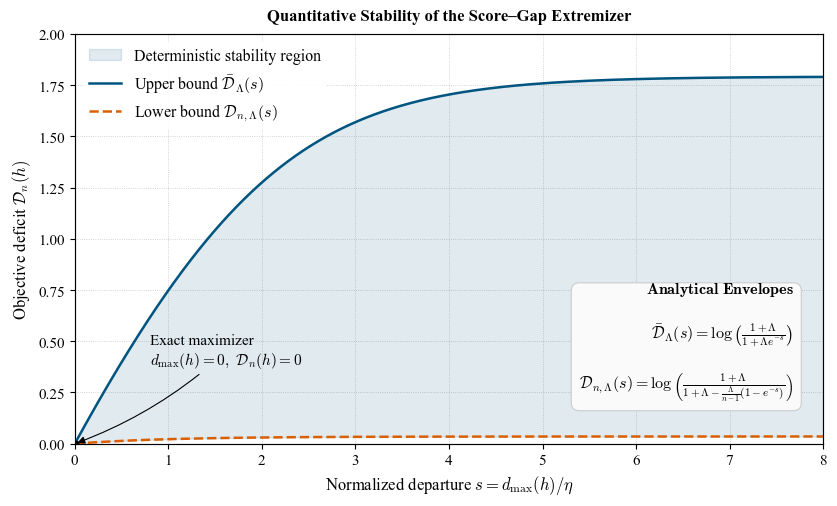

In [10]:
# ==========================================
# Figure 9
# ==========================================


plt.close("all")
plt.rcdefaults()

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern"],
        "mathtext.fontset": "cm",  # Computer Modern pur style LaTeX
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11.5,
        "axes.linewidth": 0.85,
        "grid.linewidth": 0.6,
        "axes.unicode_minus": False,
    }
)

# =============================================================================
# 2. PARAMÈTRES ET ANALYSE NUMÉRIQUE
# =============================================================================
N = 25
LAMBDA = 5.0
S_MIN, S_MAX = 0.0, 8.0
N_GRID = 1000

s = np.linspace(S_MIN, S_MAX, N_GRID, dtype=np.float64)


def lower_bound(s, n, lam):
    denom = 1.0 + lam - (lam / (n - 1.0)) * (1.0 - np.exp(-s))
    return np.log((1.0 + lam) / denom)


def upper_bound(s, lam):
    denom = 1.0 + lam * np.exp(-s)
    return np.log((1.0 + lam) / denom)


D_low = lower_bound(s, N, LAMBDA)
D_up = upper_bound(s, LAMBDA)


##########################################
fig, ax = plt.subplots(figsize=(8.5, 5.2))

COLOR_UPPER = "#005580"
COLOR_LOWER = "#D95F02"
COLOR_REGION = "#005580"

# Zone de stabilité
ax.fill_between(
    s,
    D_low,
    D_up,
    color=COLOR_REGION,
    alpha=0.12,
    label="Deterministic stability region",
    zorder=1,
)

# Courbes de bornes
line_up = ax.plot(
    s,
    D_up,
    color=COLOR_UPPER,
    linewidth=1.8,
    linestyle="-",
    label=r"Upper bound $\bar{\mathcal{D}}_{\Lambda}(s)$",
    zorder=3,
)
line_low = ax.plot(
    s,
    D_low,
    color=COLOR_LOWER,
    linewidth=1.8,
    linestyle="--",
    label=r"Lower bound $\mathcal{D}_{n,\Lambda}(s)$",
    zorder=3,
)

# Point Origine (Exact Maximizer)
ax.scatter([0.0], [0.0], color="black", s=25, zorder=5)

# Annotation discrète et élégante
ax.annotate(
    "Exact maximizer\n" r"$d_{\max}(h)=0,\ \mathcal{D}_n(h)=0$",
    xy=(0.0, 0.0),
    xytext=(0.8, 0.45),
    arrowprops=dict(
        arrowstyle="-|>",
        color="black",
        lw=0.8,
        mutation_scale=11,
        connectionstyle="arc3,rad=-0.1",
    ),
    fontsize=11.,
    ha="left",
    va="center",
)

# =============================================================================
# 4. ENCADRÉ MATHÉMATIQUE LaTeX RIGOUREUX (SANS ASCII)
# =============================================================================
box_text = (
    r"$\mathbf{Analytical\ Envelopes}$"
    "\n\n"
    r"$\bar{\mathcal{D}}_{\Lambda}(s) = \log\left(\frac{1 + \Lambda}{1 + \Lambda e^{-s}}\right)$"
    "\n\n"
    r"$\mathcal{D}_{n,\Lambda}(s) = \log\left(\frac{1 + \Lambda}{1 + \Lambda - \frac{\Lambda}{n-1}(1 - e^{-s})}\right)$"
)

ax.text(
    0.96,
    0.10,
    box_text,
    transform=ax.transAxes,
    fontsize=11.5,
    ha="right",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#FAFAFA",
        edgecolor="#CCCCCC",
        linewidth=0.8,
    ),
)

# =============================================================================
# 5. HABILLAGE ET FINITIONS
# =============================================================================
ax.set_xlabel(r"Normalized departure $s = d_{\max}(h)/\eta$")
ax.set_ylabel(r"Objective deficit $\mathcal{D}_n(h)$")
ax.set_title(
    r"Quantitative Stability of the Score–Gap Extremizer",
    pad=10,
    fontweight="bold",
)

ax.set_xlim(S_MIN, S_MAX)
ax.set_ylim(0.0, 2.0)  # Cadrage ajusté sur les données réelles
ax.grid(True, which="major", linestyle=":", linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
# Légende épurée
ax.legend(loc="upper left", frameon=True, framealpha=0.9, edgecolor="none")
plt.tight_layout()
plt.show()

